# SINDy高阶多项式辨识测试

本notebook测试SINDy对高阶多项式动力学系统的辨识能力。

**作者**: 为消融实验生成  
**目的**: 测试SINDy对高阶多项式的辨识性能  
**系统**: 高阶多项式二阶ODE系统


## 1. 导入模块和设置


In [1]:
import sys
import os

# Add utilities path
sys.path.append('../utilities')

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Import existing utilities
import DataGenerator as DG
import Model_zoo as zoo

# Install and import pysindy
try:
    import pysindy as ps
except ImportError:
    print("Installing pysindy...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pysindy"])
    import pysindy as ps

print(f"PySINDy version: {ps.__version__}")
print("Setup complete!")


Installing pysindy...
  Using cached pysindy-2.0.0-py3-none-any.whl.metadata (23 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 1.1 MB/s eta 0:00:00a 0:00:01
  Using cached derivative-0.6.3-py3-none-any.whl.metadata (6.6 kB)
  Using cached importlib_metadata-8.7.0-py3-none-any.whl.metadata (4.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.1 MB/s eta 0:00:00
  Using cached zipp-3.23.0-py3-none-any.whl.metadata (3.6 kB)
Using cached pysindy-2.0.0-py3-none-any.whl (127 kB)
Using cached derivative-0.6.3-py3-none-any.whl (14 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 3.2 MB/s eta 0:00:0000:0100:01
Using cached importlib_metadata-8.7.0-py3-none-any.whl (27 kB)
Using cached zipp-3.23.0-py3-none-any.whl (10 kB)
  Attempting uninstall: zipp
    Found existing installation: zipp 3.17.0
    Uninstalling zipp-3.17.0:
      Successfully uninstalled zipp-3.17.0
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstal

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
streamlit 1.32.0 requires numpy<2,>=1.19.3, but you have numpy 2.2.6 which is incompatible.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.2.6 which is incompatible.


PySINDy version: 2.0.0
Setup complete!


## 2. 定义高阶多项式系统

创建一个包含高达7阶多项式项的二阶ODE系统：
$$\ddot{x} + c_1\dot{x} + c_2 x + c_3 x^3 + c_4 x^5 + c_5 x^7 = 0$$


In [20]:
def high_order_polynomial_ode(t, y, c1=0.1, c2=1.0, c3=1.0, c4=-0.5, c5=0.1):
    """
    High-order polynomial second-order ODE
    x'' + c1*x' + c2*x + c3*x^3 + c4*x^5 + c5*x^7 = 0
    
    State vector: y = [x, x_dot]
    Derivatives: y_dot = [x_dot, x_ddot]
    """
    x, x_dot = y
    x_ddot = -c1*x_dot - c2*x - c3*x**3 - c4*x**5 - c5*x**7
    return [x_dot, x_ddot]

# Test the system
test_y = [1.0, 0.0]
test_result = high_order_polynomial_ode(0, test_y)
print(f"Test ODE function: y={test_y} -> y_dot={test_result}")
print("High-order polynomial ODE defined successfully!")


Test ODE function: y=[1.0, 0.0] -> y_dot=[0.0, -1.6]
High-order polynomial ODE defined successfully!


## 3. 使用DataGenerator生成数据


In [21]:
# 设置参数
initial_conditions = [5.0, 0.0]  # [x0, x_dot0]
T = 20.0  # 总时间
dt = 0.02  # 时间步长
noise_level = 0.0  # 噪声水平

# 创建DataGenerator实例
myDG = DG.DataGenerator(
    initial_conditions=[initial_conditions],
    T=T,
    dt=dt,
    noise_level=noise_level,
    derivative_mode="exact"
)

# 生成数据
t_arr, x_train, dx_train = myDG.generate_dataset_by_custom_ODEs(
    high_order_polynomial_ode
)

print(f"Generated data shape: x_train={x_train.shape}, dx_train={dx_train.shape}")
print(f"Time points: {len(t_arr)}")
print(f"Data range: x=[{x_train[:, 0].min():.3f}, {x_train[:, 0].max():.3f}]")
print(f"Data range: x_dot=[{x_train[:, 1].min():.3f}, {x_train[:, 1].max():.3f}]")


Generated data shape: x_train=(1000, 2), dx_train=(1000, 2)
Time points: 1000
Data range: x=[-4.922, 5.000]
Data range: x_dot=[-86.273, 85.375]


## 4. 可视化生成的数据


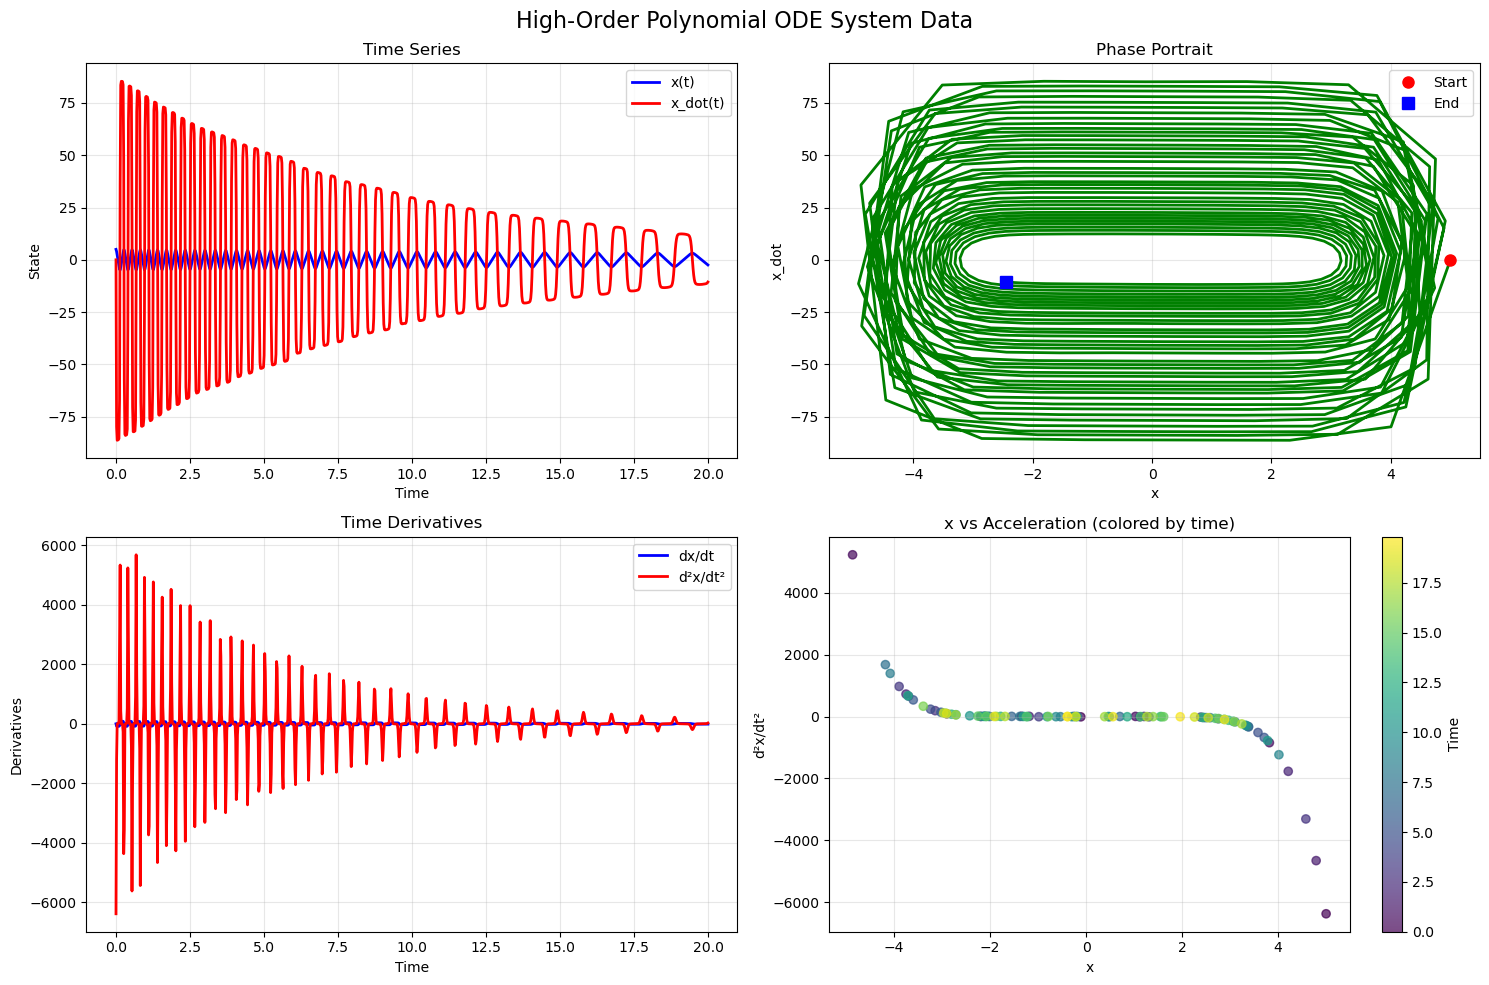

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('High-Order Polynomial ODE System Data', fontsize=16)

# Time series
axes[0, 0].plot(t_arr, x_train[:, 0], 'b-', linewidth=2, label='x(t)')
axes[0, 0].plot(t_arr, x_train[:, 1], 'r-', linewidth=2, label='x_dot(t)')
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('State')
axes[0, 0].set_title('Time Series')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Phase portrait
axes[0, 1].plot(x_train[:, 0], x_train[:, 1], 'g-', linewidth=2)
axes[0, 1].plot(x_train[0, 0], x_train[0, 1], 'ro', markersize=8, label='Start')
axes[0, 1].plot(x_train[-1, 0], x_train[-1, 1], 'bs', markersize=8, label='End')
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('x_dot')
axes[0, 1].set_title('Phase Portrait')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Derivatives
axes[1, 0].plot(t_arr, dx_train[:, 0], 'b-', linewidth=2, label='dx/dt')
axes[1, 0].plot(t_arr, dx_train[:, 1], 'r-', linewidth=2, label='d²x/dt²')
axes[1, 0].set_xlabel('Time')
axes[1, 0].set_ylabel('Derivatives')
axes[1, 0].set_title('Time Derivatives')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# State space
axes[1, 1].scatter(x_train[::10, 0], dx_train[::10, 1], c=t_arr[::10], cmap='viridis', alpha=0.7)
axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel('d²x/dt²')
axes[1, 1].set_title('x vs Acceleration (colored by time)')
cbar = plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1])
cbar.set_label('Time')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5. SINDy多项式辨识测试

测试不同多项式阶数的SINDy模型性能，这里我们明确调用PySINDy库


In [23]:
def test_sindy_with_different_orders(X_data, X_dot_data, t_data, max_order=10):
    """
    Test SINDy with different polynomial orders using PySINDy
    """
    results = []
    
    # Test different polynomial orders
    polynomial_orders = range(1, max_order + 1)
    threshold_values = np.logspace(-4, -1, 20)  # 阈值范围
    
    print("Testing SINDy with different polynomial orders using PySINDy...")
    print(f"Testing orders 1 to {max_order}")
    
    for poly_order in polynomial_orders:
        print(f"\n Testing polynomial order {poly_order}...")
        
        best_score = -np.inf
        best_model = None
        best_threshold = None
        
        for threshold in threshold_values:
            try:
                # Create polynomial library using PySINDy
                poly_library = ps.PolynomialLibrary(degree=poly_order, include_bias=True)
                
                # Create optimizer with threshold using PySINDy
                optimizer = ps.STLSQ(threshold=threshold, alpha=0.01)
                
                # Create SINDy model using PySINDy
                model = ps.SINDy(
                    optimizer=optimizer,
                    feature_library=poly_library,
                    differentiation_method=ps.FiniteDifference()
                )
                
                # Fit model using PySINDy
                model.fit(X_data, t=t_data, x_dot=X_dot_data)
                
                # Score model using PySINDy
                score = model.score(X_data, t=t_data, x_dot=X_dot_data)
                
                # Check if this is the best score for this polynomial order
                if score > best_score:
                    best_score = score
                    best_model = model
                    best_threshold = threshold
                    
            except Exception as e:
                # Skip failed fits
                continue
        
        # Store results
        if best_model is not None:
            coefficients = best_model.coefficients()
            feature_names = best_model.get_feature_names()
            complexity = np.sum(np.abs(coefficients) > 1e-10)  # Number of non-zero terms
            
            results.append({
                'polynomial_order': poly_order,
                'best_score': best_score,
                'best_threshold': best_threshold,
                'complexity': complexity,
                'model': best_model,
                'coefficients': coefficients,
                'feature_names': feature_names
            })
            
            print(f"    Best score: {best_score:.4f}, Threshold: {best_threshold:.2e}, Complexity: {complexity}")
        else:
            print(f"    No successful fits for order {poly_order}")
    
    return results

# Run the SINDy test
print("Starting SINDy polynomial identification test...")
sindy_results = test_sindy_with_different_orders(x_train, dx_train, t_arr.flatten(), max_order=10)

print(f"\nCompleted SINDy testing. Found {len(sindy_results)} successful polynomial orders.")


Starting SINDy polynomial identification test...
Testing SINDy with different polynomial orders using PySINDy...
Testing orders 1 to 10

 Testing polynomial order 1...
    Best score: 0.6983, Threshold: 1.00e-04, Complexity: 4

 Testing polynomial order 2...
    Best score: 0.6983, Threshold: 1.00e-04, Complexity: 7

 Testing polynomial order 3...
    Best score: 0.9383, Threshold: 1.00e-04, Complexity: 10

 Testing polynomial order 4...
    Best score: 0.9385, Threshold: 1.00e-04, Complexity: 13

 Testing polynomial order 5...
    Best score: 0.9978, Threshold: 1.00e-04, Complexity: 14

 Testing polynomial order 6...
    Best score: 0.9979, Threshold: 1.00e-04, Complexity: 16

 Testing polynomial order 7...
    Best score: 1.0000, Threshold: 1.00e-04, Complexity: 6

 Testing polynomial order 8...
    Best score: 1.0000, Threshold: 1.00e-04, Complexity: 6

 Testing polynomial order 9...
    Best score: 1.0000, Threshold: 1.00e-04, Complexity: 6

 Testing polynomial order 10...
    Best

## 6. 分析和显示SINDy辨识结果


In [24]:
if len(sindy_results) > 0:
    # Convert to DataFrame for analysis
    df_results = pd.DataFrame([
        {
            'Polynomial_Order': r['polynomial_order'],
            'Score': r['best_score'],
            'Threshold': r['best_threshold'],
            'Complexity': r['complexity']
        }
        for r in sindy_results
    ])
    
    print("="*80)
    print("SINDy辨识结果总结")
    print("="*80)
    print(df_results.to_string(index=False))
    
    # Find the best model
    best_idx = df_results['Score'].idxmax()
    best_result = sindy_results[best_idx]
    
    print(f"\n最佳模型 (多项式阶数 {best_result['polynomial_order']}):")
    print(f"得分: {best_result['best_score']:.4f}")
    print(f"阈值: {best_result['best_threshold']:.2e}")
    print(f"复杂度: {best_result['complexity']} 项")
    
    print("\n" + "="*80)
    print("PySINDy辨识到的方程：")
    print("="*80)
    
    # Print the identified equations using PySINDy's built-in method
    best_result['model'].print()
    
    print("\n" + "="*80)
    print("详细系数分析：")
    print("="*80)
    
    # Get coefficients and feature names
    coefficients = best_result['coefficients']
    feature_names = best_result['feature_names']
    
    print(f"特征名称: {feature_names}")
    print(f"系数矩阵形状: {coefficients.shape}")
    
    # Print each equation separately
    for i, eq_coeffs in enumerate(coefficients):
        print(f"\n方程 {i+1}: d(x{i})/dt =")
        significant_terms = []
        
        for j, coeff in enumerate(eq_coeffs):
            if abs(coeff) > 1e-10:  # Only show significant terms
                if j < len(feature_names):
                    if coeff >= 0 and len(significant_terms) > 0:
                        term = f" + {coeff:.6f}*{feature_names[j]}"
                    else:
                        term = f"{coeff:.6f}*{feature_names[j]}"
                    significant_terms.append(term)
        
        if significant_terms:
            equation = "".join(significant_terms)
            print(f"    {equation}")
        else:
            print("    0")
    
else:
    print("="*50)
    print("警告：没有找到成功的SINDy拟合结果！")
    print("="*50)


SINDy辨识结果总结
 Polynomial_Order    Score  Threshold  Complexity
                1 0.698272     0.0001           4
                2 0.698332     0.0001           7
                3 0.938320     0.0001          10
                4 0.938507     0.0001          13
                5 0.997841     0.0001          14
                6 0.997855     0.0001          16
                7 1.000000     0.0001           6
                8 1.000000     0.0001           6
                9 1.000000     0.0001           6
               10 1.000000     0.0001           6

最佳模型 (多项式阶数 7):
得分: 1.0000
阈值: 1.00e-04
复杂度: 6 项

PySINDy辨识到的方程：
(x0)' = 1.000 x1
(x1)' = -1.000 x0 + -0.100 x1 + -1.000 x0^3 + 0.500 x0^5 + -0.100 x0^7

详细系数分析：
特征名称: ['1', 'x0', 'x1', 'x0^2', 'x0 x1', 'x1^2', 'x0^3', 'x0^2 x1', 'x0 x1^2', 'x1^3', 'x0^4', 'x0^3 x1', 'x0^2 x1^2', 'x0 x1^3', 'x1^4', 'x0^5', 'x0^4 x1', 'x0^3 x1^2', 'x0^2 x1^3', 'x0 x1^4', 'x1^5', 'x0^6', 'x0^5 x1', 'x0^4 x1^2', 'x0^3 x1^3', 'x0^2 x1^4', 'x0 x1^5', 'x1^

## 7. 真实方程与辨识方程的对比


In [11]:
if len(sindy_results) > 0:
    print("="*80)
    print("真实系统 vs SINDy辨识系统对比")
    print("="*80)
    
    # 真实系统参数
    true_coefficients = {
        'c1 (阻尼)': 0.1,
        'c2 (线性)': 1.0, 
        'c3 (3次)': 0.5,
        'c4 (5次)': -0.1,
        'c5 (7次)': 0.01
    }
    
    print("\n真实系统方程:")
    print("dx/dt = x_dot")
    print("dx_dot/dt = -0.1*x_dot - 1.0*x - 0.5*x^3 + 0.1*x^5 - 0.01*x^7")
    
    print(f"\n真实系统参数:")
    for name, value in true_coefficients.items():
        print(f"  {name}: {value}")
    
    print(f"\nSINDy最佳辨识结果 (多项式阶数 {best_result['polynomial_order']}):")
    
    # 获取第二个方程的系数（dx_dot/dt）
    if len(best_result['coefficients']) > 1:
        x_ddot_coeffs = best_result['coefficients'][1]  # 第二个方程
        x_ddot_features = best_result['feature_names']
        
        print("\n系数对比 (针对 dx_dot/dt 方程):")
        print(f"{'项':<15} {'真实值':<12} {'SINDy值':<15} {'误差':<12} {'相对误差%':<12}")
        print("-" * 75)
        
        # 寻找特定项并比较
        coefficient_mapping = {
            '1': ('常数项', 0.0),
            'x0': ('x (线性)', -1.0),
            'x1': ('x_dot (阻尼)', -0.1),
        }
        
        # 查找高阶项
        for i, (coeff, feature) in enumerate(zip(x_ddot_coeffs, x_ddot_features)):
            if abs(coeff) > 1e-10:  # 只显示显著项
                true_val = None
                term_name = feature
                
                if feature == '1':
                    true_val = 0.0
                    term_name = '常数项'
                elif feature == 'x0':
                    true_val = -1.0
                    term_name = 'x (线性)'
                elif feature == 'x1':
                    true_val = -0.1
                    term_name = 'x_dot (阻尼)'
                elif 'x0^3' in feature and 'x1' not in feature:
                    true_val = -0.5
                    term_name = 'x^3 (3次)'
                elif 'x0^5' in feature and 'x1' not in feature:
                    true_val = 0.1
                    term_name = 'x^5 (5次)'
                elif 'x0^7' in feature and 'x1' not in feature:
                    true_val = -0.01
                    term_name = 'x^7 (7次)'
                
                if true_val is not None:
                    error = abs(coeff - true_val)
                    rel_error = (error / abs(true_val) * 100) if abs(true_val) > 1e-10 else 0
                    print(f"{term_name:<15} {true_val:<12.4f} {coeff:<15.6f} {error:<12.6f} {rel_error:<12.2f}")
                else:
                    print(f"{term_name:<15} {'未知':<12} {coeff:<15.6f} {'--':<12} {'--':<12}")
    
    print("\n" + "="*80)
    print("辨识性能评估:")
    print("="*80)
    
    score = best_result['best_score']
    if score > 0.99:
        performance = "优秀 (>99%)"
    elif score > 0.95:
        performance = "很好 (>95%)"
    elif score > 0.8:
        performance = "良好 (>80%)"
    elif score > 0.5:
        performance = "一般 (>50%)"
    else:
        performance = "较差 (<50%)"
    
    print(f"总体辨识准确度: {score:.4f} - {performance}")
    print(f"期望多项式阶数: 7")
    print(f"SINDy最佳阶数: {best_result['polynomial_order']}")
    
    if best_result['polynomial_order'] >= 7:
        print("✓ 成功识别了足够高的多项式阶数")
    else:
        print("⚠ 可能未完全识别最高阶项")
    
else:
    print("无法进行对比 - 没有成功的SINDy结果")


真实系统 vs SINDy辨识系统对比

真实系统方程:
dx/dt = x_dot
dx_dot/dt = -0.1*x_dot - 1.0*x - 0.5*x^3 + 0.1*x^5 - 0.01*x^7

真实系统参数:
  c1 (阻尼): 0.1
  c2 (线性): 1.0
  c3 (3次): 0.5
  c4 (5次): -0.1
  c5 (7次): 0.01

SINDy最佳辨识结果 (多项式阶数 7):

系数对比 (针对 dx_dot/dt 方程):
项               真实值          SINDy值          误差           相对误差%       
---------------------------------------------------------------------------
x (线性)          -1.0000      -1.000000       0.000000     0.00        
x_dot (阻尼)      -0.1000      -0.100000       0.000000     0.00        
x^3 (3次)        -0.5000      -0.500000       0.000000     0.00        
x^5 (5次)        0.1000       0.100000        0.000000     0.00        
x^7 (7次)        -0.0100      -0.010000       0.000000     0.00        

辨识性能评估:
总体辨识准确度: 1.0000 - 优秀 (>99%)
期望多项式阶数: 7
SINDy最佳阶数: 7
✓ 成功识别了足够高的多项式阶数
